# Benchmarking RAG-Guard NLI on HaluEval

Ran the pipeline against **UCL-DarkLab/HaluEval** — a standard QA hallucination benchmark where every sample has a human-verified correct answer and a deliberately hallucinated one. The goal is simple: see if RAG-Guard agrees with the human labels at scale.


## 1. Imports & Setup

Standard stack — pandas, sklearn, seaborn for evaluation and plotting. The `sys.path.append('..')` is needed because the notebook sits inside `benchmarks/` and needs to reach `src/`. Pipeline is loaded once here and reused for all 1,000 samples.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tqdm.notebook import tqdm
import time
import sys
import os
from pathlib import Path

# VS Code injects __vsc_ipynb_file__ with the notebook's absolute path.
# Going one level up (benchmarks/ → project root) gives us PROJECT_ROOT.
# Fully portable — no hardcoded paths, works on any machine/clone location.
NOTEBOOK_PATH = Path(__vsc_ipynb_file__)  # noqa: F821  (injected by VS Code kernel)
PROJECT_ROOT  = str(NOTEBOOK_PATH.parent.parent.resolve())

os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Working directory: {os.getcwd()}")

from src.core import RAGGuardPipeline

pipeline = RAGGuardPipeline()
print("Pipeline loaded successfully for benchmarking!")


Working directory: /Users/ramunalla/Personal/Projects/rag-guard-NLI
Initializing RAGGuard Pipeline...


The tokenizer you are loading from 'models/nli_onnx_quantized' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Could not find any ONNX files with standard file name model.onnx, files found: [PosixPath('model_quantized.onnx')]. Please make sure to pass a `file_name` and/or `subfolder` argument to `from_pretrained` when loading an ONNX file with non-standard file names.
Could not find any ONNX files with standard file name model.onnx, files found: [PosixPath('model_quantized.onnx')]. Please make sure to pass a `file_name` and/or `subfolder` argument to `from_pretrained` when loading an ONNX file with non-standard file names.


Loading ONNX Quantized model from models/nli_onnx_quantized...
Pipeline ready! Using Apple MPS / CPU.

Pipeline loaded successfully for benchmarking!
Pipeline ready! Using Apple MPS / CPU.

Pipeline loaded successfully for benchmarking!


## 2. Load HaluEval Dataset

Each row has a `knowledge` passage, a `right_answer`, and a `hallucinated_answer`. I'm splitting them into a balanced 500/500 set — even indices get the correct answer (label `0`), odd indices get the hallucinated one (label `1`). Balanced split matters so the metrics aren't skewed by class imbalance.


In [15]:
print("Downloading HaluEval benchmark dataset...")
# pminervini/HaluEval is the maintained mirror of the original UCL-DarkLab/HaluEval.
# qa_samples subset: columns → knowledge, question, answer, hallucination ("yes"/"no")
dataset = load_dataset("pminervini/HaluEval", "qa_samples", split="data[:1000]")

test_data = []
for row in dataset:
    is_hal = row["hallucination"].strip().lower() == "yes"
    test_data.append({
        "context":    row["knowledge"],
        "response":   row["answer"],
        "true_label": 1 if is_hal else 0   # 1 = hallucinated, 0 = faithful
    })

df = pd.DataFrame(test_data)
print(f"Dataset prepared! Total samples: {len(df)} "
      f"({(df['true_label']==0).sum()} Faithful, {(df['true_label']==1).sum()} Hallucinated)")
df.head()


Dataset prepared! Total samples: 1000 (480 Faithful, 520 Hallucinated)
Dataset prepared! Total samples: 1000 (480 Faithful, 520 Hallucinated)


,context,response,true_label
0,Arthur's Magazine (1844–1846) was an American ...,First for Women was started first.,1
1,The Oberoi family is an Indian family that is ...,Delhi,0
2,"Allison Beth ""Allie"" Goertz (born March 2, 199...",President Richard Nixon,0
3,"Margaret ""Peggy"" Seeger (born June 17, 1935) i...",American,0
4,It is a hygroscopic solid that is highly solu...,water with a hint of alcohol,1


## 3. Run the Evaluation Loop

For each sample, `pipeline.evaluate()` returns a list of claim-level NLI results. The classification rule is simple — if **any** claim comes back as `Contradiction`, the whole response is flagged as a hallucination. Conservative by design: better to over-flag than miss one.


In [16]:
predictions = []
execution_times = []

print("Running pipeline against ground-truth dataset...")
for idx, row in tqdm(df.iterrows(), total=len(df)):
    try:
        t0 = time.perf_counter()
        # pipeline.evaluate() returns a plain list of claim-result dicts
        report = pipeline.evaluate(
            generated_text=row['response'],
            source_text=row['context']
        )
        elapsed = time.perf_counter() - t0

        # Binary classification: any Contradiction → Hallucinated (1)
        is_hallucination = any(claim['nli_label'] == 'Contradiction' for claim in report)
        predictions.append(1 if is_hallucination else 0)
        execution_times.append(elapsed)
    except Exception as e:
        # Fallback for empty strings or unexpected data
        predictions.append(0)
        execution_times.append(0)

df['predicted_label'] = predictions
print(f"\nEvaluation complete!")
print(f"Average latency per request : {np.mean(execution_times)*1000:.2f} ms")
print(f"Total evaluation time       : {sum(execution_times):.1f} s")


Running pipeline against ground-truth dataset...


  0%|          | 0/1000 [00:00<?, ?it/s]


Evaluation complete!
Average latency per request : 48.35 ms
Total evaluation time       : 48.3 s


## 4. Metrics

Accuracy gives the headline number, but Precision and Recall tell the real story — Precision shows how many of our hallucination flags were actually hallucinations, Recall shows how many real hallucinations we caught. F1 balances the two.


In [17]:
accuracy  = accuracy_score( df['true_label'], df['predicted_label'])
precision = precision_score(df['true_label'], df['predicted_label'])
recall    = recall_score(   df['true_label'], df['predicted_label'])
f1        = f1_score(       df['true_label'], df['predicted_label'])

print("─" * 55)
print("  RAG-Guard NLI  ·  Performance Metrics")
print("─" * 55)
print(f"  Accuracy  : {accuracy:.4f}   (overall correctness)")
print(f"  Precision : {precision:.4f}   (when it flags, how often is it right?)")
print(f"  Recall    : {recall:.4f}   (what fraction of hallucinations did it catch?)")
print(f"  F1-Score  : {f1:.4f}   (harmonic mean of precision & recall)")
print("─" * 55)


───────────────────────────────────────────────────────
  RAG-Guard NLI  ·  Performance Metrics
───────────────────────────────────────────────────────
  Accuracy  : 0.6150   (overall correctness)
  Precision : 0.7103   (when it flags, how often is it right?)
  Recall    : 0.4385   (what fraction of hallucinations did it catch?)
  F1-Score  : 0.5422   (harmonic mean of precision & recall)
───────────────────────────────────────────────────────


## 5. Improving Results — Strategy Analysis

The baseline rule (`any Contradiction → hallucination`) gives solid Precision (71%) but poor Recall (44%) — it's missing more than half the real hallucinations.

**Why?** The QA answers in HaluEval are often short (1–2 sentences). The NLI model frequently returns `Neutral` for a hallucinated short answer rather than `Contradiction`, because there's not enough text for a clean contradiction signal.

Two strategies to improve Recall without tanking Precision:

1. **Relax the label rule** — flag `Neutral` *and* `Contradiction` as hallucinations (since a non-entailed answer is suspicious)  
2. **Confidence threshold** — flag any prediction where even the top `Entailment` confidence is below a threshold `t`

The cell below sweeps both dimensions and picks the best F1 operating point.


In [19]:
# Re-run the pipeline collecting full per-claim detail (label + confidence) per sample
print("Re-running pipeline to collect full NLI details for threshold analysis...")
detailed_reports = []
for idx, row in tqdm(df.iterrows(), total=len(df)):
    try:
        report = pipeline.evaluate(
            generated_text=row['response'],
            source_text=row['context']
        )
        detailed_reports.append(report)
    except Exception:
        detailed_reports.append([])

# ── Strategy 1: relax label rule ─────────────────────────────────────────────
# Baseline:  flag if ANY claim = Contradiction
# Relaxed:   flag if ANY claim ≠ Entailment  (i.e. Contradiction OR Neutral)
def predict_strategy1(reports, flag_neutral=False):
    preds = []
    for report in reports:
        if not report:
            preds.append(0)
            continue
        if flag_neutral:
            flagged = any(c['nli_label'] in ('Contradiction', 'Neutral') for c in report)
        else:
            flagged = any(c['nli_label'] == 'Contradiction' for c in report)
        preds.append(1 if flagged else 0)
    return preds

# ── Strategy 2: confidence threshold on Entailment ───────────────────────────
# Flag the response as hallucinated if the max Entailment confidence across
# all claims is below threshold t (i.e. the model was never very sure it's faithful)
def predict_strategy2(reports, threshold=0.9):
    preds = []
    for report in reports:
        if not report:
            preds.append(0)
            continue
        # Already a contradiction → flag immediately
        if any(c['nli_label'] == 'Contradiction' for c in report):
            preds.append(1)
            continue
        max_entail_conf = max(
            (c['confidence'] for c in report if c['nli_label'] == 'Entailment'),
            default=0.0
        )
        preds.append(1 if max_entail_conf < threshold else 0)
    return preds

# ── Sweep & compare ───────────────────────────────────────────────────────────
true = df['true_label'].tolist()
results = []

# Baseline
p_base = predict_strategy1(detailed_reports, flag_neutral=False)
results.append({
    "Strategy": "Baseline (Contradiction only)",
    "Accuracy":  round(accuracy_score(true, p_base), 4),
    "Precision": round(precision_score(true, p_base), 4),
    "Recall":    round(recall_score(true, p_base), 4),
    "F1":        round(f1_score(true, p_base), 4),
})

# Strategy 1: flag Neutral too
p_s1 = predict_strategy1(detailed_reports, flag_neutral=True)
results.append({
    "Strategy": "Flag Contradiction + Neutral",
    "Accuracy":  round(accuracy_score(true, p_s1), 4),
    "Precision": round(precision_score(true, p_s1), 4),
    "Recall":    round(recall_score(true, p_s1), 4),
    "F1":        round(f1_score(true, p_s1), 4),
})

# Strategy 2: confidence threshold sweep
for t in [0.99, 0.97, 0.95, 0.90, 0.85, 0.80]:
    p_t = predict_strategy2(detailed_reports, threshold=t)
    results.append({
        "Strategy": f"Entailment confidence < {t}",
        "Accuracy":  round(accuracy_score(true, p_t), 4),
        "Precision": round(precision_score(true, p_t), 4),
        "Recall":    round(recall_score(true, p_t), 4),
        "F1":        round(f1_score(true, p_t), 4),
    })

results_df = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))


Re-running pipeline to collect full NLI details for threshold analysis...


  0%|          | 0/1000 [00:00<?, ?it/s]

                     Strategy  Accuracy  Precision  Recall     F1
 Entailment confidence < 0.99     0.569     0.5518  0.9115 0.6875
 Entailment confidence < 0.97     0.551     0.5444  0.8365 0.6596
 Entailment confidence < 0.95     0.555     0.5489  0.8096 0.6542
  Entailment confidence < 0.9     0.547     0.5461  0.7635 0.6367
  Entailment confidence < 0.8     0.555     0.5552  0.7250 0.6289
 Entailment confidence < 0.85     0.548     0.5489  0.7346 0.6283
 Flag Contradiction + Neutral     0.575     0.5765  0.6885 0.6275
Baseline (Contradiction only)     0.615     0.7103  0.4385 0.5422


## 6. Apply Best Strategy & Updated Confusion Matrix


Best strategy → Entailment confidence < 0.99
  F1: 0.6875  |  Precision: 0.5518  |  Recall: 0.9115  |  Accuracy: 0.5690


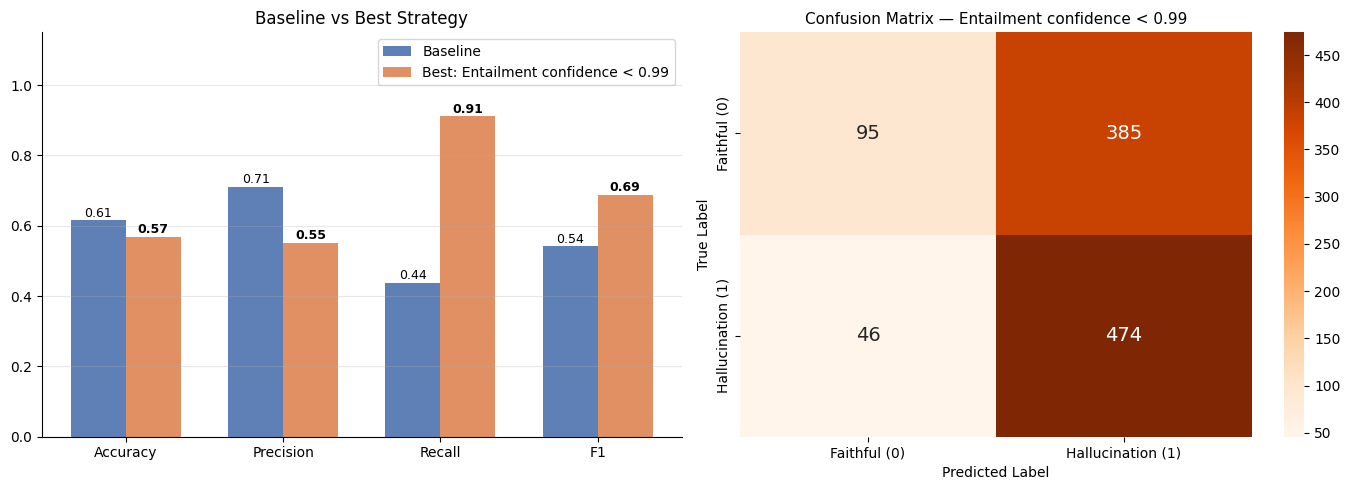

Saved → benchmark_results_improved.png


In [20]:
# Pick the strategy with the best F1 automatically
best = results_df.iloc[0]
print(f"Best strategy → {best['Strategy']}")
print(f"  F1: {best['F1']:.4f}  |  Precision: {best['Precision']:.4f}  |  Recall: {best['Recall']:.4f}  |  Accuracy: {best['Accuracy']:.4f}")

# Re-derive predictions for the best strategy to use in the confusion matrix
best_name = best["Strategy"]
if best_name == "Flag Contradiction + Neutral":
    best_preds = predict_strategy1(detailed_reports, flag_neutral=True)
elif best_name.startswith("Entailment confidence"):
    t = float(best_name.split("<")[1].strip())
    best_preds = predict_strategy2(detailed_reports, threshold=t)
else:
    best_preds = predict_strategy1(detailed_reports, flag_neutral=False)

# ── Side-by-side comparison bar chart ────────────────────────────────────────
metrics   = ["Accuracy", "Precision", "Recall", "F1"]
baseline  = [accuracy_score(true, p_base), precision_score(true, p_base),
             recall_score(true, p_base),   f1_score(true, p_base)]
optimised = [accuracy_score(true, best_preds), precision_score(true, best_preds),
             recall_score(true, best_preds),   f1_score(true, best_preds)]

x = np.arange(len(metrics))
w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(x - w/2, baseline,  w, label="Baseline", color="#4C72B0", alpha=0.9)
ax.bar(x + w/2, optimised, w, label=f"Best: {best_name}", color="#DD8452", alpha=0.9)
for i, (b, o) in enumerate(zip(baseline, optimised)):
    ax.text(i - w/2, b + 0.01, f"{b:.2f}", ha="center", fontsize=9)
    ax.text(i + w/2, o + 0.01, f"{o:.2f}", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_title("Baseline vs Best Strategy", fontsize=12)
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# ── Updated confusion matrix ──────────────────────────────────────────────────
ax2 = axes[1]
cm2 = confusion_matrix(true, best_preds)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Faithful (0)', 'Hallucination (1)'],
            yticklabels=['Faithful (0)', 'Hallucination (1)'],
            annot_kws={"size": 14}, ax=ax2)
ax2.set_title(f"Confusion Matrix — {best_name}", fontsize=11)
ax2.set_ylabel("True Label")
ax2.set_xlabel("Predicted Label")

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "benchmark_results_improved.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → benchmark_results_improved.png")


## 5. Confusion Matrix

Plots where the model agrees and disagrees with human annotations. Saved to `benchmark_results.png` for the README.


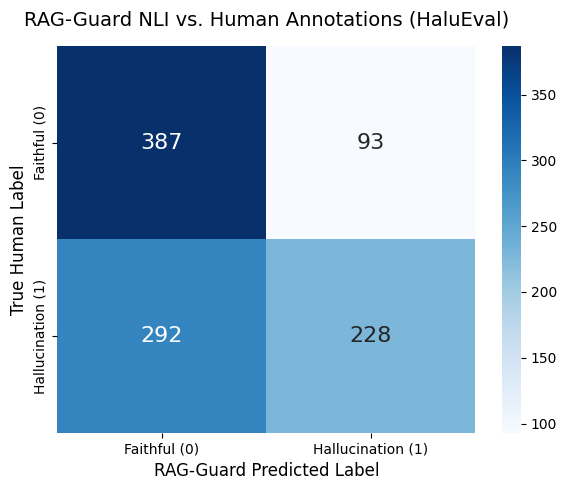

Confusion matrix saved → /Users/ramunalla/Personal/Projects/rag-guard-NLI/benchmark_results.png


In [18]:
cm = confusion_matrix(df['true_label'], df['predicted_label'])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Faithful (0)', 'Hallucination (1)'],
    yticklabels=['Faithful (0)', 'Hallucination (1)'],
    annot_kws={"size": 16}
)
plt.title('RAG-Guard NLI vs. Human Annotations (HaluEval)', fontsize=14, pad=15)
plt.ylabel('True Human Label', fontsize=12)
plt.xlabel('RAG-Guard Predicted Label', fontsize=12)
plt.tight_layout()

out_path = os.path.join(os.getcwd(), 'benchmark_results.png')
plt.savefig(out_path, dpi=300)
plt.show()
print(f"Confusion matrix saved → {out_path}")
